# Plot EXTRACT Spatial Profiles And Traces

This notebook is organized as small functions so each step can be checked independently:

1. Load EXTRACT output
2. Load ACTSort labels
3. Load a maximum intensity projection image
4. Reshape and validate spatial profiles / traces
5. Plot selected spatial profiles on the MIP image
6. Plot example traces for selected cells

The code is designed to start from three inputs:

- an EXTRACT output `.mat` file
- an ACTSort labels file
- a maximum intensity projection image


In [18]:
from pathlib import Path
from typing import Iterable, Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio

try:
    import mat73
except ImportError:
    mat73 = None

try:
    import tifffile
except ImportError:
    tifffile = None

from IPython.display import display

plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'


In [19]:
# Update these paths before running.
extract_output_path = Path(r"/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/20260505_125714_389/gray_denoised_converted_concat_ds_mc_Aligned_20260505_125714_389.mat")
labels_path = Path(r"/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/20260505_125714_389/precomputed_output_LABELS.mat")
# if creating a mip in FIJI from input.h5, should be rotated 90 degrees right and flipped vertically to align with ACTsort 
mip_image_path = Path(r"/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/1500_2500_20260618_114459_104/gray_denoised_converted_concat_ds_mc_Aligned_1500_2500_max_projection_rotated_flipped.tif")

# Optional knobs for loading and cell selection.
extract_output_var_name = "output"
labels_mat_var_name = None
labels_cell_id_col = None
labels_value_col = None
labels_are_one_based = True

# Only needed if spatial_weights are stored as a flattened 2D array.
image_shape = None  # Example: (height, width)

# Example filtering / plotting choices.
label_values_to_keep = None  # Example: ["accepted", "keep"] or [1]
example_cell_ids = None      # Example: [1, 5, 12] using label numbering
n_overlay_cells = 20
n_trace_cells = 10
trace_start_frame = None
trace_end_frame = None

# Saving / display options for the white+colored overlay figure.
show_overlay_numeric_labels = True
overlay_save_path = None  # Example: Path(r"/path/to/overlay_profiles.svg") or .png
overlay_save_dpi = 600

# Saving options for the colored trace figure.
# Use .svg or .pdf for Illustrator-editable vector output.
trace_save_path = None    # Example: Path(r"/path/to/colored_traces.svg")


In [20]:
def _load_mat_file(path: Path):
    try:
        return sio.loadmat(path, simplify_cells=True)
    except NotImplementedError:
        try:
            import mat73
        except ImportError as exc:
            raise ImportError(
                "This is a MATLAB v7.3 file. Run `%pip install mat73` in the notebook, "
                "then rerun this cell."
            ) from exc
        return mat73.loadmat(path)


def load_extract_output(path: Path, output_var_name: str = "output"):
    data = _load_mat_file(path)
    if output_var_name not in data:
        raise KeyError(f"Could not find variable '{output_var_name}' in {path}")
    output = data[output_var_name]
    if not isinstance(output, dict):
        raise TypeError(
            f"Expected '{output_var_name}' to load as a dict-like MATLAB struct, got {type(output)}"
        )
    required = {"spatial_weights", "temporal_weights"}
    missing = sorted(required.difference(output.keys()))
    if missing:
        raise KeyError(f"Missing required EXTRACT fields: {missing}")
    return output


def load_labels_table(
    path: Path,
    labels_mat_var_name: Optional[str] = None,
):
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".tsv", ".txt"}:
        return pd.read_csv(path, sep="\t")
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".pkl":
        return pd.read_pickle(path)
    if suffix == ".mat":
        data = _load_mat_file(path)
        if labels_mat_var_name is not None:
            labels = data[labels_mat_var_name]
        else:
            candidates = {k: v for k, v in data.items() if not k.startswith("__")}
            if len(candidates) != 1:
                raise ValueError(
                    "MAT labels file contains multiple variables. Set labels_mat_var_name explicitly."
                )
            labels = next(iter(candidates.values()))
        if isinstance(labels, pd.DataFrame):
            return labels
        if isinstance(labels, dict):
            return pd.DataFrame(labels)
        return pd.DataFrame(labels)
    raise ValueError(f"Unsupported labels file type: {path.suffix}")


def load_mip_image(path: Path):
    suffix = path.suffix.lower()
    if suffix in {".tif", ".tiff"}:
        if tifffile is None:
            raise ImportError("tifffile is required to read .tif/.tiff images")
        image = tifffile.imread(path)
    else:
        image = plt.imread(path)
    image = np.asarray(image)
    if image.ndim == 3:
        image = image.max(axis=-1)
    return image.astype(np.float32)


def summarize_loaded_inputs(output, labels_df: pd.DataFrame, mip_image: np.ndarray):
    spatial = np.asarray(output["spatial_weights"])
    traces = np.asarray(output["temporal_weights"])
    print(f"spatial_weights shape: {spatial.shape}")
    print(f"temporal_weights shape: {traces.shape}")
    print(f"labels shape: {labels_df.shape}")
    print(f"mip image shape: {mip_image.shape}")
    display(labels_df.head())


In [21]:
def _infer_cell_count_from_traces(traces: np.ndarray) -> int:
    if traces.ndim != 2:
        raise ValueError(f"Expected temporal_weights to be 2D, got shape {traces.shape}")
    return min(traces.shape)


def standardize_extract_arrays(output, image_shape: Optional[tuple[int, int]] = None):
    spatial = np.asarray(output["spatial_weights"])
    traces = np.asarray(output["temporal_weights"])
    n_cells_guess = _infer_cell_count_from_traces(traces)

    if traces.shape[1] == n_cells_guess:
        traces_2d = traces
    elif traces.shape[0] == n_cells_guess:
        traces_2d = traces.T
    else:
        raise ValueError(f"Could not align temporal_weights shape {traces.shape}")

    n_cells = traces_2d.shape[1]

    if spatial.ndim == 3:
        if spatial.shape[2] != n_cells:
            raise ValueError(
                f"3D spatial_weights has {spatial.shape[2]} cells but traces have {n_cells}"
            )
        spatial_3d = spatial
    elif spatial.ndim == 2:
        if image_shape is None:
            raise ValueError(
                "spatial_weights is 2D. Set image_shape=(height, width) so it can be reshaped."
            )
        n_pixels = int(np.prod(image_shape))
        if spatial.shape[0] == n_pixels and spatial.shape[1] == n_cells:
            spatial_3d = np.reshape(spatial, (*image_shape, n_cells), order="F")
        elif spatial.shape[1] == n_pixels and spatial.shape[0] == n_cells:
            spatial_3d = np.reshape(spatial.T, (*image_shape, n_cells), order="F")
        else:
            raise ValueError(
                f"Could not reshape spatial_weights shape {spatial.shape} using image_shape={image_shape}"
            )
    else:
        raise ValueError(f"Unsupported spatial_weights shape: {spatial.shape}")

    return spatial_3d.astype(np.float32), traces_2d.astype(np.float32)


def _find_first_matching_column(columns: Iterable[str], candidates: Iterable[str]):
    lookup = {str(col).lower(): col for col in columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


def standardize_labels_table(
    labels_df: pd.DataFrame,
    n_cells: int,
    cell_id_col: Optional[str] = None,
    value_col: Optional[str] = None,
    labels_are_one_based: bool = True,
):
    labels_df = labels_df.copy()

    if cell_id_col is None:
        cell_id_col = _find_first_matching_column(
            labels_df.columns,
            ["cell_id", "cell", "roi", "roi_id", "component", "unit", "neuron", "index"],
        )
    if value_col is None:
        value_col = _find_first_matching_column(
            labels_df.columns,
            ["label", "labels", "classification", "class", "accepted", "iscell", "keep"],
        )

    if cell_id_col is None:
        labels_df["cell_id"] = np.arange(1, len(labels_df) + 1)
        cell_id_col = "cell_id"
    if value_col is None:
        raise ValueError(
            "Could not infer a label column. Set labels_value_col explicitly."
        )

    standardized = labels_df[[cell_id_col, value_col]].copy()
    standardized.columns = ["cell_id", "label"]
    standardized = standardized.dropna(subset=["cell_id"])
    standardized["cell_id"] = standardized["cell_id"].astype(int)

    if labels_are_one_based:
        standardized["cell_index"] = standardized["cell_id"] - 1
    else:
        standardized["cell_index"] = standardized["cell_id"]

    standardized = standardized[(standardized["cell_index"] >= 0) & (standardized["cell_index"] < n_cells)]
    standardized = standardized.sort_values("cell_index").reset_index(drop=True)
    return standardized


def filter_cell_indices(
    labels_df: pd.DataFrame,
    label_values_to_keep: Optional[Iterable] = None,
    example_cell_ids: Optional[Iterable[int]] = None,
    labels_are_one_based: bool = True,
):
    subset = labels_df.copy()
    if label_values_to_keep is not None:
        subset = subset[subset["label"].isin(label_values_to_keep)]
    if example_cell_ids is not None:
        if labels_are_one_based:
            keep_indices = {int(cell_id) - 1 for cell_id in example_cell_ids}
        else:
            keep_indices = {int(cell_id) for cell_id in example_cell_ids}
        subset = subset[subset["cell_index"].isin(keep_indices)]
    return subset


def print_selection_summary(labels_df: pd.DataFrame):
    print(f"Selected cells: {len(labels_df)}")
    if "label" in labels_df:
        display(labels_df["label"].value_counts(dropna=False))
    display(labels_df.head())


In [22]:
def normalize_image(image: np.ndarray, lower_pct: float = 1, upper_pct: float = 99.5):
    lo, hi = np.percentile(image, [lower_pct, upper_pct])
    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)
    clipped = np.clip(image, lo, hi)
    return ((clipped - lo) / (hi - lo)).astype(np.float32)


def get_component_image(spatial_3d: np.ndarray, cell_index: int):
    component = spatial_3d[:, :, cell_index]
    component = np.asarray(component, dtype=np.float32)
    component[component < 0] = 0
    return component


def component_threshold(component_image: np.ndarray, percentile: float = 97):
    positive = component_image[component_image > 0]
    if positive.size == 0:
        return np.inf
    return float(np.percentile(positive, percentile))


def mask_from_intensity_fraction(component_image: np.ndarray, intensity_fraction: float = 0.95):
    component = np.asarray(component_image, dtype=np.float32).copy()
    component[component < 0] = 0

    total = component.sum()
    if total <= 0:
        return np.zeros_like(component, dtype=bool)

    flat = component.ravel()
    order = np.argsort(flat)[::-1]
    sorted_vals = flat[order]
    cumulative = np.cumsum(sorted_vals)
    cutoff_idx = np.searchsorted(cumulative, intensity_fraction * total, side="left")

    keep = np.zeros_like(flat, dtype=bool)
    keep[order[: cutoff_idx + 1]] = True
    return keep.reshape(component.shape)


def plot_spatial_profiles_on_mip_by_intensity(
    mip_image: np.ndarray,
    spatial_3d: np.ndarray,
    selected_labels: pd.DataFrame,
    max_cells: int = 20,
    intensity_fraction: float = 0.95,
    annotate: bool = True,
):
    selected_labels = selected_labels.head(max_cells)
    mip_norm = normalize_image(mip_image)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mip_norm, cmap="gray")
    colors = plt.cm.hsv(np.linspace(0, 1, max(len(selected_labels), 2), endpoint=False))

    for color, (_, row) in zip(colors, selected_labels.iterrows()):
        cell_index = int(row["cell_index"])
        component = get_component_image(spatial_3d, cell_index)
        mask = mask_from_intensity_fraction(component, intensity_fraction=intensity_fraction)

        if not np.any(mask):
            continue

        ax.contour(mask.astype(float), levels=[0.5], colors=[color], linewidths=1.5)

        if annotate:
            ys, xs = np.where(mask)
            label_text = str(row.get("cell_id", cell_index + 1))
            ax.text(xs.mean(), ys.mean(), label_text, color=color, fontsize=8, ha="center", va="center")

    ax.set_title(f"Spatial profiles containing {intensity_fraction:.0%} of total intensity")
    ax.set_axis_off()
    plt.show()


def select_cells_by_id(labels_df: pd.DataFrame, cell_ids: Iterable[int], labels_are_one_based: bool = True):
    cell_ids = list(cell_ids)
    if len(cell_ids) == 0:
        return labels_df.iloc[0:0].copy()

    if labels_are_one_based:
        keep_indices = [int(cell_id) - 1 for cell_id in cell_ids]
        order_map = {int(cell_id): i for i, cell_id in enumerate(cell_ids)}
        subset = labels_df[labels_df["cell_index"].isin(keep_indices)].copy()
        subset["plot_order"] = subset["cell_id"].map(order_map)
    else:
        keep_indices = [int(cell_id) for cell_id in cell_ids]
        order_map = {int(cell_id): i for i, cell_id in enumerate(cell_ids)}
        subset = labels_df[labels_df["cell_index"].isin(keep_indices)].copy()
        subset["plot_order"] = subset["cell_index"].map(order_map)

    subset = subset.sort_values("plot_order").drop(columns="plot_order")
    return subset.reset_index(drop=True)


def _make_color_lookup(selected_labels: pd.DataFrame, cmap_name: str = "hsv"):
    if selected_labels.empty:
        return {}
    colors = plt.get_cmap(cmap_name)(np.linspace(0, 1, max(len(selected_labels), 2), endpoint=False))
    return {
        int(row["cell_index"]): color
        for color, (_, row) in zip(colors, selected_labels.iterrows())
    }


def plot_spatial_profiles_white_and_colored_by_intensity(
    mip_image: np.ndarray,
    spatial_3d: np.ndarray,
    white_border_labels: pd.DataFrame,
    colored_border_labels: pd.DataFrame,
    intensity_fraction: float = 0.95,
    annotate_colored: bool = True,
    white_linewidth: float = 1.2,
    colored_linewidth: float = 2.0,
    cmap_name: str = "hsv",
    save_path: Optional[Path] = None,
    save_dpi: int = 600,
):
    mip_norm = normalize_image(mip_image)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mip_norm, cmap="gray")

    for _, row in white_border_labels.iterrows():
        cell_index = int(row["cell_index"])
        component = get_component_image(spatial_3d, cell_index)
        mask = mask_from_intensity_fraction(component, intensity_fraction=intensity_fraction)
        if np.any(mask):
            ax.contour(mask.astype(float), levels=[0.5], colors=["white"], linewidths=white_linewidth)

    color_lookup = _make_color_lookup(colored_border_labels, cmap_name=cmap_name)

    for _, row in colored_border_labels.iterrows():
        cell_index = int(row["cell_index"])
        component = get_component_image(spatial_3d, cell_index)
        mask = mask_from_intensity_fraction(component, intensity_fraction=intensity_fraction)
        if not np.any(mask):
            continue

        color = color_lookup[cell_index]
        ax.contour(mask.astype(float), levels=[0.5], colors=[color], linewidths=colored_linewidth)

        if annotate_colored:
            ys, xs = np.where(mask)
            if len(xs):
                label_text = str(row.get("cell_id", cell_index + 1))
                ax.text(xs.mean(), ys.mean(), label_text, color=color, fontsize=8, ha="center", va="center")

    ax.set_title(f"White and colored spatial profiles containing {intensity_fraction:.0%} of total intensity")
    ax.set_axis_off()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=save_dpi, bbox_inches="tight")

    plt.show()
    return color_lookup


def plot_colored_cell_traces(
    traces_2d: np.ndarray,
    colored_border_labels: pd.DataFrame,
    color_lookup: dict,
    start_frame: Optional[int] = None,
    end_frame: Optional[int] = None,
    zscore_each_trace: bool = False,
    save_path: Optional[Path] = None,
):
    if colored_border_labels.empty:
        raise ValueError("No colored-border cells available to plot traces")

    start = 0 if start_frame is None else int(start_frame)
    stop = traces_2d.shape[0] if end_frame is None else int(end_frame)
    frames = np.arange(start, stop)
    cell_indices = colored_border_labels["cell_index"].astype(int).to_numpy()
    trace_block = traces_2d[start:stop, cell_indices].astype(np.float32)

    if zscore_each_trace:
        mu = trace_block.mean(axis=0, keepdims=True)
        sigma = trace_block.std(axis=0, keepdims=True)
        sigma[sigma == 0] = 1
        trace_block = (trace_block - mu) / sigma

    offsets = []
    running_offset = 0.0
    for i in range(trace_block.shape[1]):
        y = trace_block[:, i]
        y = y - np.nanmin(y)
        span = float(np.nanmax(y))
        if not np.isfinite(span):
            span = 0.0
        offsets.append(running_offset)
        running_offset += span + 0.5

    fig, ax = plt.subplots(figsize=(12, 8))

    for i, (_, row) in enumerate(colored_border_labels.iterrows()):
        cell_index = int(row["cell_index"])
        color = color_lookup.get(cell_index, "tab:red")
        y = trace_block[:, i]
        y = y - np.nanmin(y)
        ax.plot(frames, y + offsets[i], color=color, linewidth=1.5)
        label_text = str(row.get("cell_id", cell_index + 1))
        ax.text(frames[0], offsets[i], label_text, color=color, fontsize=8, va="bottom")

    ax.set_title("Example traces for colored-border cells")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Offset traces")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()


def plot_single_component_debug(mip_image: np.ndarray, spatial_3d: np.ndarray, cell_index: int):
    component = get_component_image(spatial_3d, cell_index)
    mip_norm = normalize_image(mip_image)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(mip_norm, cmap="gray")
    axes[0].set_title("MIP")
    axes[0].axis("off")
    axes[1].imshow(component, cmap="magma")
    axes[1].set_title(f"Component {cell_index}")
    axes[1].axis("off")
    axes[2].imshow(mip_norm, cmap="gray")
    level = component_threshold(component)
    if np.isfinite(level):
        axes[2].contour(component, levels=[level], colors=["cyan"], linewidths=1.5)
    axes[2].set_title("Overlay debug")
    axes[2].axis("off")
    plt.show()


def plot_example_traces(
    traces_2d: np.ndarray,
    selected_labels: pd.DataFrame,
    n_trace_cells: int = 10,
    start_frame: Optional[int] = None,
    end_frame: Optional[int] = None,
    zscore_each_trace: bool = False,
):
    subset = selected_labels.head(n_trace_cells)
    if subset.empty:
        raise ValueError("No cells available to plot traces")

    start = 0 if start_frame is None else int(start_frame)
    stop = traces_2d.shape[0] if end_frame is None else int(end_frame)
    frames = np.arange(start, stop)
    trace_block = traces_2d[start:stop, subset["cell_index"].astype(int).to_numpy()]

    if zscore_each_trace:
        mu = trace_block.mean(axis=0, keepdims=True)
        sigma = trace_block.std(axis=0, keepdims=True)
        sigma[sigma == 0] = 1
        trace_block = (trace_block - mu) / sigma

    offsets = np.arange(trace_block.shape[1], dtype=np.float32)
    fig, ax = plt.subplots(figsize=(12, 8))

    for i, (_, row) in enumerate(subset.iterrows()):
        y = trace_block[:, i]
        y = y - np.nanmin(y)
        ax.plot(frames, y + offsets[i] * (np.nanmax(y) + 1e-6 + 0.5), linewidth=1)
        ax.text(frames[0], offsets[i] * (np.nanmax(y) + 1e-6 + 0.5), str(row.get("cell_id", row["cell_index"] + 1)), fontsize=8)

    ax.set_title("Example cell traces")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Offset traces")
    plt.show()


In [23]:
output = load_extract_output(extract_output_path, output_var_name=extract_output_var_name)
labels_raw = load_labels_table(labels_path, labels_mat_var_name=labels_mat_var_name)
mip_image = load_mip_image(mip_image_path)

spatial_3d, traces_2d = standardize_extract_arrays(output, image_shape=image_shape)

In [24]:
labels_raw

,labels_ex,labels_ml,labels_overall
0,-1,-1,-1
1,0,1,1
2,0,-1,-1
3,0,1,1
4,1,-1,1
...,...,...,...
680,0,-1,-1
681,-1,-1,-1
682,1,1,1
683,0,1,1


In [25]:
list(labels_raw[labels_raw['labels_ex']==1].index)

[4,
 10,
 15,
 36,
 37,
 40,
 42,
 45,
 48,
 50,
 54,
 63,
 65,
 67,
 79,
 82,
 94,
 106,
 116,
 124,
 131,
 132,
 137,
 139,
 141,
 151,
 152,
 156,
 158,
 159,
 167,
 185,
 187,
 190,
 193,
 202,
 203,
 204,
 208,
 217,
 229,
 237,
 250,
 257,
 262,
 264,
 265,
 277,
 280,
 282,
 283,
 286,
 290,
 295,
 302,
 318,
 322,
 329,
 333,
 337,
 350,
 351,
 352,
 354,
 355,
 379,
 380,
 381,
 397,
 400,
 402,
 409,
 415,
 421,
 422,
 430,
 431,
 437,
 444,
 445,
 446,
 450,
 457,
 467,
 468,
 472,
 473,
 475,
 478,
 483,
 489,
 504,
 508,
 511,
 512,
 531,
 542,
 543,
 549,
 563,
 566,
 567,
 586,
 595,
 597,
 599,
 610,
 626,
 633,
 637,
 644,
 652,
 658,
 663,
 667,
 668,
 675,
 677,
 682]

In [26]:
labels_cell_id_col = None
labels_value_col = "labels_ex"
labels_df = standardize_labels_table(
    labels_raw,
    n_cells=spatial_3d.shape[2],
    cell_id_col=labels_cell_id_col,
    value_col=labels_value_col,
    labels_are_one_based=labels_are_one_based,
)

In [27]:
summarize_loaded_inputs(output, labels_df, mip_image)
print(f"Standardized spatial array: {spatial_3d.shape}")
print(f"Standardized trace array: {traces_2d.shape}")

spatial_weights shape: (290, 291, 685)
temporal_weights shape: (247698, 685)
labels shape: (685, 3)
mip image shape: (290, 291)


,cell_id,label,cell_index
0,1,-1,0
1,2,0,1
2,3,0,2
3,4,0,3
4,5,1,4


Standardized spatial array: (290, 291, 685)
Standardized trace array: (247698, 685)


In [31]:
# Example: two groups of cells for the same projection image.
# White-border cells provide context; colored-border cells are the subset
# whose traces will be plotted in matching colors.
white_border_cell_ids = list(labels_raw[labels_raw['labels_ex']==1].index)
colored_border_cell_ids = [559, 9, 25, 42, 43, 47, 51, 71]
intensity_fraction = 0.95

white_border_labels = select_cells_by_id(
    labels_df,
    white_border_cell_ids,
    labels_are_one_based=labels_are_one_based,
)

colored_border_labels = select_cells_by_id(
    labels_df,
    colored_border_cell_ids,
    labels_are_one_based=labels_are_one_based,
)

print("White-border cells")
print_selection_summary(white_border_labels)
print("Colored-border cells")
print_selection_summary(colored_border_labels)


White-border cells
Selected cells: 119


label
 0    87
 1    23
-1     9
Name: count, dtype: int64

,cell_id,label,cell_index
0,4,0,3
1,10,0,9
2,15,-1,14
3,36,0,35
4,37,1,36


Colored-border cells
Selected cells: 8


label
0    6
1    2
Name: count, dtype: int64

,cell_id,label,cell_index
0,559,0,558
1,9,0,8
2,25,0,24
3,42,0,41
4,43,1,42


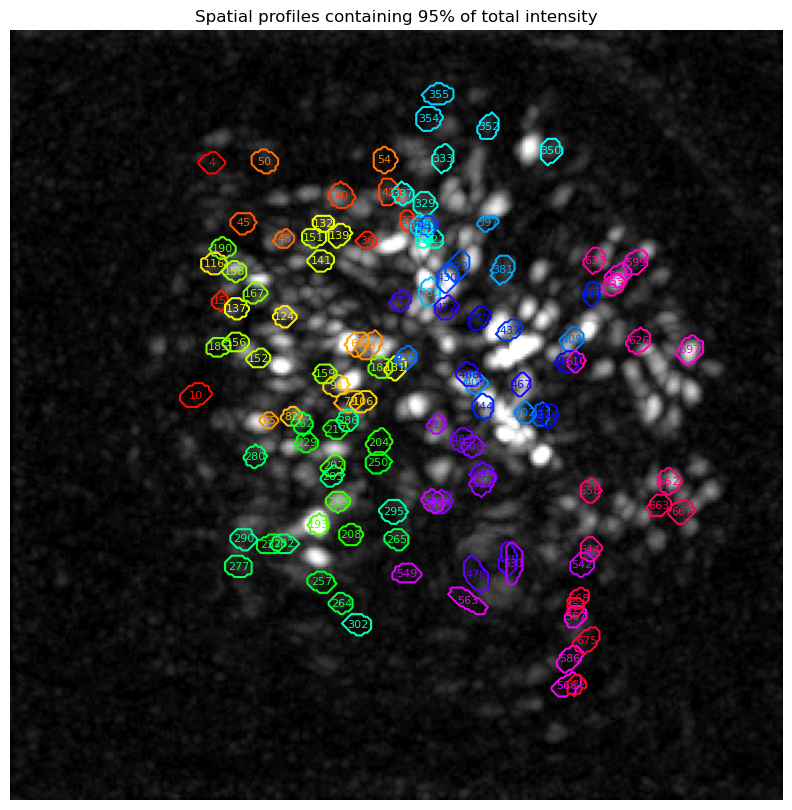

In [32]:
plot_spatial_profiles_on_mip_by_intensity(
    mip_image,
    spatial_3d,
    white_border_labels,
    max_cells=len(white_border_cell_ids),
    intensity_fraction=intensity_fraction,
)


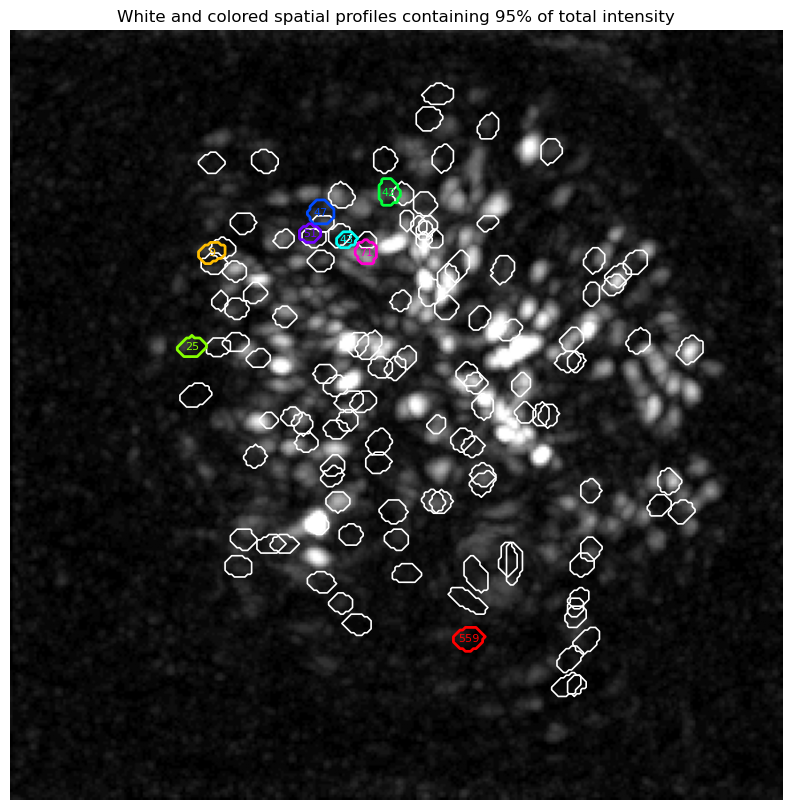

In [33]:
show_overlay_numeric_labels = True
overlay_save_path = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/1500_2500_20260618_114459_104/contours_eg_whole_session.svg'   # example: Path(r"/path/to/overlay_profiles.svg") or .png
overlay_save_dpi = 600
trace_save_path = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays/m388/1500_2500_20260618_114459_104/traces_eg_whole_session.svg'     # example: Path(r"/path/to/colored_traces.svg")

color_lookup = plot_spatial_profiles_white_and_colored_by_intensity(
    mip_image,
    spatial_3d,
    white_border_labels,
    colored_border_labels,
    intensity_fraction=intensity_fraction,
    annotate_colored=show_overlay_numeric_labels,
    save_path=overlay_save_path,
    save_dpi=overlay_save_dpi,
)


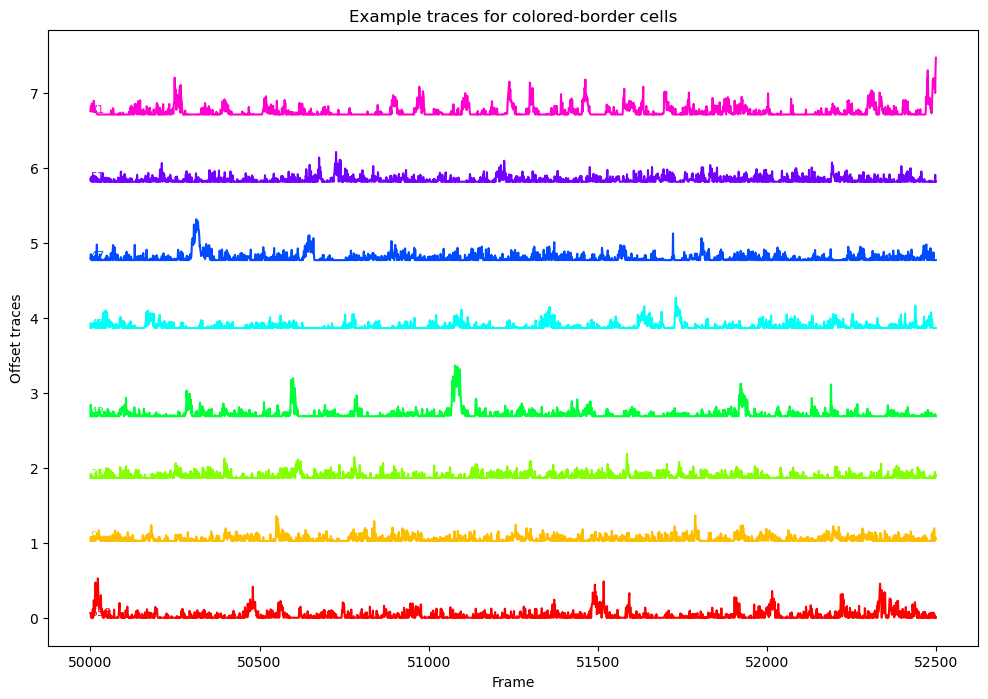

In [36]:
plot_colored_cell_traces(
    traces_2d,
    colored_border_labels,
    color_lookup,
    start_frame=50000,
    end_frame=52500,
    save_path=trace_save_path,
)


In [ ]:
# Optional debug for a single cell after the selection cell has run.
# plot_single_component_debug(mip_image, spatial_3d, cell_index=int(colored_border_labels.iloc[0]["cell_index"]))
